In [2]:
# Cell 1 — Imports, Device, Reproducibility

import os
import gc
import json
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

import seaborn as sns

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

Device: cuda
CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [3]:
# Cell 2 — Configuration

from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")

# HAM10000 dataset path
HAM10000_ROOT = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000")

# Try to locate DCGAN dataset automatically
dcgan_roots = []

for p in KAGGLE_INPUT.rglob("*"):
    if p.is_dir() and "dcgan" in str(p).lower():
        dcgan_roots.append(p)

print("Possible DCGAN roots:")
for p in dcgan_roots:
    print(p)

# Pick the dataset folder that contains synthetic/
DCGAN_ROOT = None

for p in dcgan_roots:
    if (p / "synthetic").exists():
        DCGAN_ROOT = p
        break

# Fallback: search any synthetic folder inside a dcgan path
if DCGAN_ROOT is None:
    for p in KAGGLE_INPUT.rglob("synthetic"):
        if "dcgan" in str(p).lower():
            DCGAN_ROOT = p.parent
            break

assert DCGAN_ROOT is not None, "Could not find DCGAN dataset root containing synthetic/ folder."

DCGAN_SYNTHETIC_ROOT = DCGAN_ROOT / "synthetic"

# HAM10000 paths
HAM_METADATA_PATH = HAM10000_ROOT / "HAM10000_metadata.csv"
HAM_IMAGE_DIR_1 = HAM10000_ROOT / "HAM10000_images_part_1"
HAM_IMAGE_DIR_2 = HAM10000_ROOT / "HAM10000_images_part_2"

# Output paths
OUTPUT_ROOT = KAGGLE_WORKING / "model2_swin_b_se_dcgan_outputs"
MODEL_DIR = OUTPUT_ROOT / "saved_models"
PLOT_DIR = OUTPUT_ROOT / "plots"
LOG_DIR = OUTPUT_ROOT / "logs"

for d in [OUTPUT_ROOT, MODEL_DIR, PLOT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Model / training config
IMG_SIZE = 224
NUM_CLASSES = 7

BATCH_SIZE = 16
NUM_EPOCHS = 30
LR = 5e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

USE_AMP = True
USE_SYNTHETIC_DCGAN = True

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_IDX.items()}

print("\nHAM10000 root:", HAM10000_ROOT)
print("HAM10000 root exists:", HAM10000_ROOT.exists())
print("HAM metadata exists:", HAM_METADATA_PATH.exists())
print("HAM image dir 1 exists:", HAM_IMAGE_DIR_1.exists())
print("HAM image dir 2 exists:", HAM_IMAGE_DIR_2.exists())

print("\nDCGAN root:", DCGAN_ROOT)
print("DCGAN synthetic root:", DCGAN_SYNTHETIC_ROOT)
print("DCGAN synthetic root exists:", DCGAN_SYNTHETIC_ROOT.exists())

print("\nClass mapping:")
print(CLASS_TO_IDX)

print("\nOutput root:", OUTPUT_ROOT)

Possible DCGAN roots:
/kaggle/input/datasets/umaraftab174/dcgan-dataset
/kaggle/input/datasets/umaraftab174/dcgan-dataset/synthetic
/kaggle/input/datasets/umaraftab174/dcgan-dataset/gan_samples
/kaggle/input/datasets/umaraftab174/dcgan-dataset/gan_data
/kaggle/input/datasets/umaraftab174/dcgan-dataset/gan_ckpt
/kaggle/input/datasets/umaraftab174/dcgan-dataset/synthetic/mel
/kaggle/input/datasets/umaraftab174/dcgan-dataset/synthetic/vasc
/kaggle/input/datasets/umaraftab174/dcgan-dataset/synthetic/df
/kaggle/input/datasets/umaraftab174/dcgan-dataset/synthetic/bkl
/kaggle/input/datasets/umaraftab174/dcgan-dataset/synthetic/akiec
/kaggle/input/datasets/umaraftab174/dcgan-dataset/synthetic/bcc
/kaggle/input/datasets/umaraftab174/dcgan-dataset/gan_data/mel
/kaggle/input/datasets/umaraftab174/dcgan-dataset/gan_data/vasc
/kaggle/input/datasets/umaraftab174/dcgan-dataset/gan_data/df
/kaggle/input/datasets/umaraftab174/dcgan-dataset/gan_data/bkl
/kaggle/input/datasets/umaraftab174/dcgan-dataset/

In [4]:
# Cell 3 — Load HAM10000 Metadata and Real Image Paths

import pandas as pd

assert HAM_METADATA_PATH.exists(), f"HAM10000 metadata not found: {HAM_METADATA_PATH}"

real_df = pd.read_csv(HAM_METADATA_PATH)

print("HAM10000 metadata loaded from:")
print(HAM_METADATA_PATH)

display(real_df.head())

# Build image_id -> path mapping from both image folders
image_id_to_path = {}

for image_dir in [HAM_IMAGE_DIR_1, HAM_IMAGE_DIR_2]:
    assert image_dir.exists(), f"Image directory not found: {image_dir}"

    for p in image_dir.glob("*.jpg"):
        image_id_to_path[p.stem] = str(p)

print("Total HAM10000 images indexed:", len(image_id_to_path))

real_df["path"] = real_df["image_id"].map(image_id_to_path)

missing_paths = real_df["path"].isna().sum()
print("Missing image paths:", missing_paths)

assert missing_paths == 0, "Some HAM10000 image paths are missing."

real_df = real_df[["image_id", "dx", "path"]].copy()
real_df["source"] = "real"

real_df = real_df[real_df["dx"].isin(CLASS_NAMES)].reset_index(drop=True)

print("\nReal dataset size:", len(real_df))

print("\nReal dataset class distribution:")
display(real_df["dx"].value_counts().reindex(CLASS_NAMES))

HAM10000 metadata loaded from:
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Total HAM10000 images indexed: 10015
Missing image paths: 0

Real dataset size: 10015

Real dataset class distribution:


dx
akiec     327
bcc       514
bkl      1099
df        115
mel      1113
nv       6705
vasc      142
Name: count, dtype: int64

In [5]:
# Cell 4 — Load DCGAN Synthetic Images Only

synthetic_df = None

if USE_SYNTHETIC_DCGAN:
    assert DCGAN_SYNTHETIC_ROOT.exists(), f"DCGAN synthetic folder not found: {DCGAN_SYNTHETIC_ROOT}"

    image_extensions = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

    synthetic_records = []

    for cls in CLASS_NAMES:
        # DCGAN should only contain minority classes, but this is safe.
        class_dir = DCGAN_SYNTHETIC_ROOT / cls

        if not class_dir.exists():
            print(f"Class folder not found, skipping: {class_dir}")
            continue

        class_files = []

        for p in class_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in image_extensions:
                class_files.append(p)

        print(f"{cls:6s}: {len(class_files)} synthetic images")

        for p in class_files:
            synthetic_records.append({
                "image_id": p.stem,
                "dx": cls,
                "path": str(p),
                "source": "dcgan_synthetic"
            })

    synthetic_df = pd.DataFrame(synthetic_records)

    # If folders were not exact class names, fallback by filename/path inference
    if len(synthetic_df) == 0:
        print("\nNo images found using class folders. Trying fallback path inference...")

        all_synth_files = [
            p for p in DCGAN_SYNTHETIC_ROOT.rglob("*")
            if p.is_file() and p.suffix.lower() in image_extensions
        ]

        fallback_records = []

        for p in all_synth_files:
            path_lower = str(p).lower()
            filename_lower = p.name.lower()

            inferred_cls = None

            for cls in CLASS_NAMES:
                if f"/{cls}/" in path_lower or cls in filename_lower:
                    inferred_cls = cls
                    break

            if inferred_cls is not None:
                fallback_records.append({
                    "image_id": p.stem,
                    "dx": inferred_cls,
                    "path": str(p),
                    "source": "dcgan_synthetic"
                })

        synthetic_df = pd.DataFrame(fallback_records)

    assert len(synthetic_df) > 0, "No DCGAN synthetic images found."

    synthetic_df = synthetic_df[synthetic_df["dx"].isin(CLASS_NAMES)].reset_index(drop=True)

    print("\nDCGAN synthetic dataset size:", len(synthetic_df))

    print("\nDCGAN synthetic class distribution:")
    display(synthetic_df["dx"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int))

    display(synthetic_df.head())

else:
    print("USE_SYNTHETIC_DCGAN is False. Proceeding with real images only.")
    synthetic_df = None

akiec : 4141 synthetic images
bcc   : 4061 synthetic images
bkl   : 3741 synthetic images
df    : 4265 synthetic images
mel   : 3832 synthetic images
Class folder not found, skipping: /kaggle/input/datasets/umaraftab174/dcgan-dataset/synthetic/nv
vasc  : 4245 synthetic images

DCGAN synthetic dataset size: 24285

DCGAN synthetic class distribution:


dx
akiec    4141
bcc      4061
bkl      3741
df       4265
mel      3832
nv          0
vasc     4245
Name: count, dtype: int64

,image_id,dx,path,source
0,akiec_syn_02009,akiec,/kaggle/input/datasets/umaraftab174/dcgan-data...,dcgan_synthetic
1,akiec_syn_02612,akiec,/kaggle/input/datasets/umaraftab174/dcgan-data...,dcgan_synthetic
2,akiec_syn_02764,akiec,/kaggle/input/datasets/umaraftab174/dcgan-data...,dcgan_synthetic
3,akiec_syn_02330,akiec,/kaggle/input/datasets/umaraftab174/dcgan-data...,dcgan_synthetic
4,akiec_syn_00950,akiec,/kaggle/input/datasets/umaraftab174/dcgan-data...,dcgan_synthetic


In [6]:
# Cell 5 — Real-Only Train/Validation/Test Split

# First split: train_temp and test
train_temp_df, test_df = train_test_split(
    real_df,
    test_size=0.15,
    stratify=real_df["dx"],
    random_state=SEED
)

# Second split: train and val
train_real_df, val_df = train_test_split(
    train_temp_df,
    test_size=0.1765,  # gives around 15% val from full dataset
    stratify=train_temp_df["dx"],
    random_state=SEED
)

train_real_df = train_real_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Real train size:", len(train_real_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nReal train distribution:")
display(train_real_df["dx"].value_counts().sort_index())

print("\nValidation distribution:")
display(val_df["dx"].value_counts().sort_index())

print("\nTest distribution:")
display(test_df["dx"].value_counts().sort_index())

Real train size: 7009
Validation size: 1503
Test size: 1503

Real train distribution:


dx
akiec     229
bcc       360
bkl       769
df         80
mel       779
nv       4693
vasc       99
Name: count, dtype: int64


Validation distribution:


dx
akiec      49
bcc        77
bkl       165
df         18
mel       167
nv       1006
vasc       21
Name: count, dtype: int64


Test distribution:


dx
akiec      49
bcc        77
bkl       165
df         17
mel       167
nv       1006
vasc       22
Name: count, dtype: int64

In [7]:
# Cell 6 — Add DCGAN Synthetic Images to Training Only

if synthetic_df is not None and len(synthetic_df) > 0:
    synthetic_df = synthetic_df[synthetic_df["dx"].isin(CLASS_NAMES)].reset_index(drop=True)

    # Optional cap per synthetic class.
    # Useful if synthetic images are too many or noisy.
    # Set None to use all DCGAN synthetic images.
    MAX_SYNTHETIC_PER_CLASS = None

    if MAX_SYNTHETIC_PER_CLASS is not None:
        synthetic_capped = []

        for cls in CLASS_NAMES:
            cls_df = synthetic_df[synthetic_df["dx"] == cls]

            if len(cls_df) > MAX_SYNTHETIC_PER_CLASS:
                cls_df = cls_df.sample(
                    n=MAX_SYNTHETIC_PER_CLASS,
                    random_state=SEED
                )

            synthetic_capped.append(cls_df)

        synthetic_df = pd.concat(synthetic_capped, ignore_index=True)

    train_df = pd.concat(
        [train_real_df, synthetic_df],
        ignore_index=True
    )

else:
    train_df = train_real_df.copy()

train_df = train_df.reset_index(drop=True)

print("Final training size:", len(train_df))

print("\nFinal training distribution:")
display(train_df["dx"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int))

print("\nSource distribution:")
display(train_df["source"].value_counts())

Final training size: 31294

Final training distribution:


dx
akiec    4370
bcc      4421
bkl      4510
df       4345
mel      4611
nv       4693
vasc     4344
Name: count, dtype: int64


Source distribution:


source
dcgan_synthetic    24285
real                7009
Name: count, dtype: int64

In [8]:
# Cell 7 — Image Transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.12,
        hue=0.03
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
# Cell 8 — Dataset and DataLoaders

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = row["path"]
        label_name = row["dx"]
        label = self.class_to_idx[label_name]

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


train_dataset = HAM10000Dataset(
    dataframe=train_df,
    class_to_idx=CLASS_TO_IDX,
    transform=train_transform
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    class_to_idx=CLASS_TO_IDX,
    transform=eval_transform
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    class_to_idx=CLASS_TO_IDX,
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1956
Val batches: 94
Test batches: 94


In [10]:
# Cell 9 — Class Weights

train_counts = train_df["dx"].value_counts().reindex(CLASS_NAMES).fillna(0).values

total_train = train_counts.sum()

class_weights = total_train / (NUM_CLASSES * train_counts)
class_weights = np.nan_to_num(class_weights, nan=0.0, posinf=0.0, neginf=0.0)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

weights_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "train_count": train_counts.astype(int),
    "class_weight": class_weights
})

display(weights_df)

weights_df.to_csv(LOG_DIR / "class_weights.csv", index=False)

,class,train_count,class_weight
0,akiec,4370,1.023014
1,bcc,4421,1.011213
2,bkl,4510,0.991258
3,df,4345,1.028900
4,mel,4611,0.969545
5,nv,4693,0.952604
6,vasc,4344,1.029137


In [11]:
# Cell 10 — Define SE-Net Attention Block

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden_dim = max(channels // reduction, 16)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, hidden_dim, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        x shape: B × C × H × W
        """
        b, c, h, w = x.shape

        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)

        return x * y

In [12]:
# Cell 11 — Define Swin Transformer-B + SE-Net Attention Hybrid Model

class SwinB_SE_Model(nn.Module):
    def __init__(
        self,
        num_classes=7,
        dropout=0.4,
        se_reduction=16,
        pretrained=True
    ):
        super().__init__()

        if pretrained:
            weights = models.Swin_B_Weights.IMAGENET1K_V1
        else:
            weights = None

        swin = models.swin_b(weights=weights)

        # Torchvision Swin structure:
        # swin.features -> output B × H × W × C
        # swin.norm     -> LayerNorm over C
        # swin.permute  -> B × C × H × W
        # swin.avgpool  -> pooling
        # swin.head     -> classifier

        self.features = swin.features
        self.norm = swin.norm
        self.permute = swin.permute

        # For Swin-B final channels = 1024
        self.feature_channels = swin.head.in_features

        self.se_block = SEBlock(
            channels=self.feature_channels,
            reduction=se_reduction
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_channels),
            nn.Dropout(dropout),
            nn.Linear(self.feature_channels, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # x: B × 3 × 224 × 224

        x = self.features(x)
        # x: B × 7 × 7 × 1024

        x = self.norm(x)
        # x: B × 7 × 7 × 1024

        x = self.permute(x)
        # x: B × 1024 × 7 × 7

        x = self.se_block(x)
        # x: B × 1024 × 7 × 7

        x = self.pool(x)
        # x: B × 1024 × 1 × 1

        x = torch.flatten(x, 1)
        # x: B × 1024

        logits = self.classifier(x)
        # logits: B × 7

        return logits


def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model


model = SwinB_SE_Model(
    num_classes=NUM_CLASSES,
    dropout=0.4,
    se_reduction=16,
    pretrained=True
).to(device)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
    model = nn.DataParallel(model)
else:
    print("Using single GPU or CPU")

# Quick forward test
test_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)

with torch.no_grad():
    test_logits = model(test_x)

print("Test input shape:", test_x.shape)
print("Test output shape:", test_logits.shape)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/swin_b-68c6b09e.pth" to /root/.cache/torch/hub/checkpoints/swin_b-68c6b09e.pth


100%|██████████| 335M/335M [00:01<00:00, 227MB/s] 


Using 2 GPUs with DataParallel
Test input shape: torch.Size([2, 3, 224, 224])
Test output shape: torch.Size([2, 7])
Total parameters: 87,404,735
Trainable parameters: 87,404,735


In [13]:
# Cell 12 — Optional Warm-Up Freeze Strategy

USE_WARMUP_FREEZE = False
WARMUP_EPOCHS = 3

if USE_WARMUP_FREEZE:
    base_model = unwrap_model(model)

    for param in base_model.features.parameters():
        param.requires_grad = False

    for param in base_model.norm.parameters():
        param.requires_grad = False

    print("Backbone frozen for warm-up.")

else:
    print("Warm-up freeze disabled. Full fine-tuning from start.")

Warm-up freeze disabled. Full fine-tuning from start.


In [14]:
# Cell 13 — Loss, Optimizer, Scheduler, AMP

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print("Criterion:", criterion)
print("Optimizer:", optimizer)
print("Scheduler:", scheduler)
print("AMP enabled:", USE_AMP)

Criterion: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 5e-05
    lr: 5e-05
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.CosineAnnealingLR object at 0x7f31a2b316d0>
AMP enabled: True


/tmp/ipykernel_57/3288399235.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [15]:
# Cell 14 — Training and Validation Functions

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        pbar.set_postfix({"loss": loss.item()})

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_bal_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        running_loss += loss.item() * images.size(0)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_bal_acc, macro_f1, all_labels, all_preds, all_probs

In [16]:
# Cell 15 — Train Model

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_bal_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "val_macro_f1": [],
    "lr": []
}

best_val_bal_acc = -1.0
best_model_path = MODEL_DIR / "best_swin_b_se_model.pth"

print("Starting training...")

for epoch in range(1, NUM_EPOCHS + 1):

    # Optional: unfreeze after warm-up
    if USE_WARMUP_FREEZE and epoch == WARMUP_EPOCHS + 1:
        base_model = unwrap_model(model)

        for param in base_model.features.parameters():
            param.requires_grad = True

        for param in base_model.norm.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS - WARMUP_EPOCHS,
            eta_min=1e-6
        )

        print("Backbone unfrozen. Full fine-tuning started.")

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss, train_acc, train_bal_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=device
    )

    val_loss, val_acc, val_bal_acc, val_macro_f1, val_labels, val_preds, val_probs = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_bal_acc"].append(train_bal_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_bal_acc"].append(val_bal_acc)
    history["val_macro_f1"].append(val_macro_f1)
    history["lr"].append(current_lr)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train Bal Acc: {train_bal_acc:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Bal Acc: {val_bal_acc:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )

    print(f"LR: {current_lr:.8f}")

    if val_bal_acc > best_val_bal_acc:
        best_val_bal_acc = val_bal_acc

        torch.save({
            "epoch": epoch,
            "model_state_dict": unwrap_model(model).state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_bal_acc": best_val_bal_acc,
            "class_to_idx": CLASS_TO_IDX,
            "idx_to_class": IDX_TO_CLASS,
            "config": {
                "img_size": IMG_SIZE,
                "num_classes": NUM_CLASSES,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "model": "Swin Transformer-B + SE-Net Attention"
            }
        }, best_model_path)

        print(f"Best model saved: {best_model_path}")

    history_df = pd.DataFrame(history)
    history_df.to_csv(LOG_DIR / "training_history.csv", index=False)

print("\nTraining complete.")
print("Best validation balanced accuracy:", best_val_bal_acc)

Starting training...

Epoch 1/30


Training:   0%|          | 0/1956 [00:00<?, ?it/s]

/tmp/ipykernel_57/1869375937.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

/tmp/ipykernel_57/1869375937.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

Training:   0%|          | 0/1956 [00:00<?, ?it/s]

/tmp/ipykernel_57/1869375937.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

/tmp/ipykernel_57/1869375937.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Train Loss: 0.0030 | Train Acc: 0.9989 | Train Bal Acc: 0.9989
Val Loss: 0.5230 | Val Acc: 0.9128 | Val Bal Acc: 0.8486 | Val Macro F1: 0.8596
LR: 0.00000100

Training complete.
Best validation balanced accuracy: 0.8826049724591992


,epoch,train_loss,train_acc,train_bal_acc,val_loss,val_acc,val_bal_acc,val_macro_f1,lr
25,26,0.005928,0.997955,0.998004,0.477056,0.912176,0.870835,0.862597,0.000003
26,27,0.003841,0.998626,0.998656,0.464146,0.918829,0.867516,0.869955,0.000002
27,28,0.003355,0.998626,0.998656,0.498523,0.912841,0.855677,0.857004,0.000002
28,29,0.004537,0.998594,0.998631,0.496269,0.912176,0.852822,0.857320,0.000001
29,30,0.002985,0.998914,0.998946,0.523047,0.912841,0.848592,0.859635,0.000001


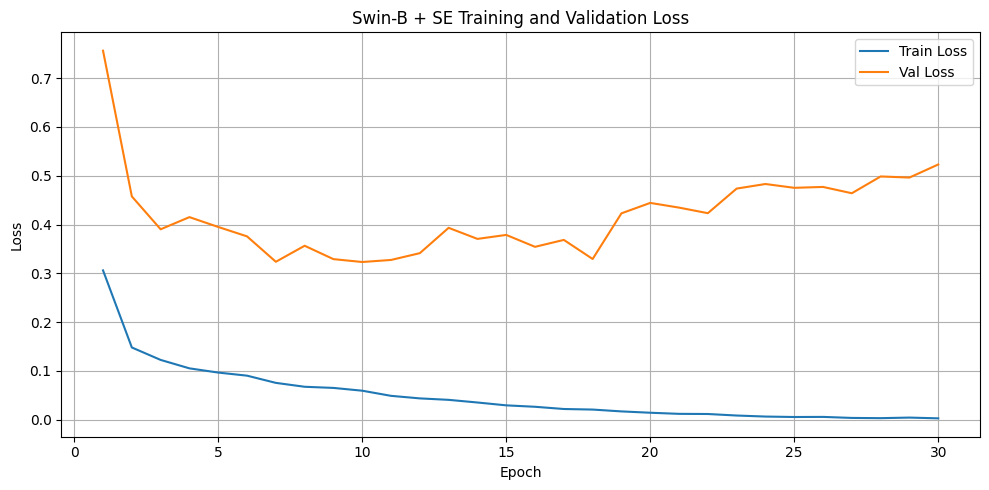

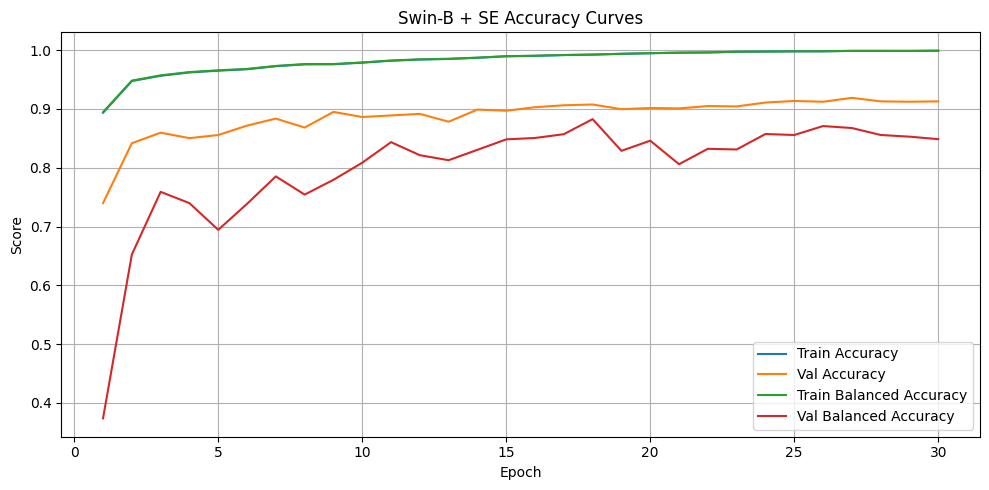

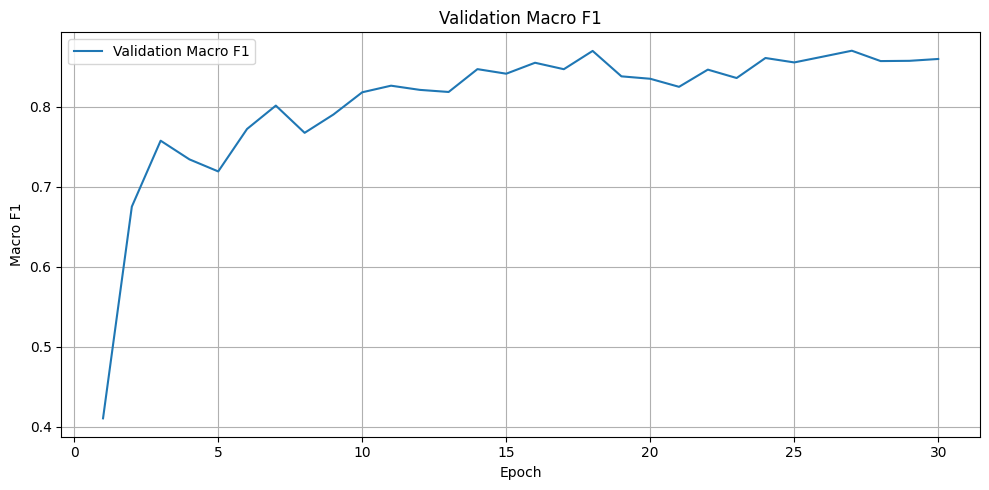

In [30]:
# Cell 16 — Plot Training Curves

history_df = pd.DataFrame(history)
display(history_df.tail())

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Swin-B + SE Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOT_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val Accuracy")
plt.plot(history_df["epoch"], history_df["train_bal_acc"], label="Train Balanced Accuracy")
plt.plot(history_df["epoch"], history_df["val_bal_acc"], label="Val Balanced Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Swin-B + SE Accuracy Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOT_DIR / "accuracy_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation Macro F1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOT_DIR / "macro_f1_curve.png", dpi=200)
plt.show()

In [31]:
# Cell 17 — Load Best Model

checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

unwrap_model(model).load_state_dict(checkpoint["model_state_dict"])

print("Loaded best model from:", best_model_path)
print("Best epoch:", checkpoint["epoch"])
print("Best validation balanced accuracy:", checkpoint["best_val_bal_acc"])

Loaded best model from: /kaggle/working/model2_swin_b_se_dcgan_outputs/saved_models/best_swin_b_se_model.pth
Best epoch: 18
Best validation balanced accuracy: 0.8826049724591992


In [32]:
# Cell 18 — Final Test Evaluation

test_loss, test_acc, test_bal_acc, test_macro_f1, test_labels, test_preds, test_probs = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device
)

test_precision_macro = precision_score(test_labels, test_preds, average="macro", zero_division=0)
test_recall_macro = recall_score(test_labels, test_preds, average="macro", zero_division=0)
test_f1_macro = f1_score(test_labels, test_preds, average="macro", zero_division=0)

test_precision_weighted = precision_score(test_labels, test_preds, average="weighted", zero_division=0)
test_recall_weighted = recall_score(test_labels, test_preds, average="weighted", zero_division=0)
test_f1_weighted = f1_score(test_labels, test_preds, average="weighted", zero_division=0)

# AUC needs one-hot labels
test_labels_onehot = np.eye(NUM_CLASSES)[test_labels]

try:
    test_auc_macro_ovr = roc_auc_score(
        test_labels_onehot,
        test_probs,
        average="macro",
        multi_class="ovr"
    )
except Exception as e:
    print("AUC calculation failed:", e)
    test_auc_macro_ovr = np.nan

results = {
    "test_loss": test_loss,
    "test_accuracy": test_acc,
    "test_balanced_accuracy": test_bal_acc,
    "test_precision_macro": test_precision_macro,
    "test_recall_macro": test_recall_macro,
    "test_f1_macro": test_f1_macro,
    "test_precision_weighted": test_precision_weighted,
    "test_recall_weighted": test_recall_weighted,
    "test_f1_weighted": test_f1_weighted,
    "test_auc_macro_ovr": test_auc_macro_ovr
}

results_df = pd.DataFrame([results])
display(results_df)

results_df.to_csv(LOG_DIR / "test_results_summary.csv", index=False)

print("\nClassification report:")
report = classification_report(
    test_labels,
    test_preds,
    target_names=CLASS_NAMES,
    zero_division=0
)

print(report)

with open(LOG_DIR / "classification_report.txt", "w") as f:
    f.write(report)

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

/tmp/ipykernel_57/1869375937.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


,test_loss,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_auc_macro_ovr
0,0.347214,0.90153,0.871146,0.869339,0.871146,0.867843,0.901946,0.90153,0.901231,0.986571



Classification report:
              precision    recall  f1-score   support

       akiec       0.75      0.92      0.83        49
         bcc       0.90      0.81      0.85        77
         bkl       0.83      0.82      0.83       165
          df       1.00      0.88      0.94        17
         mel       0.75      0.72      0.73       167
          nv       0.95      0.95      0.95      1006
        vasc       0.92      1.00      0.96        22

    accuracy                           0.90      1503
   macro avg       0.87      0.87      0.87      1503
weighted avg       0.90      0.90      0.90      1503



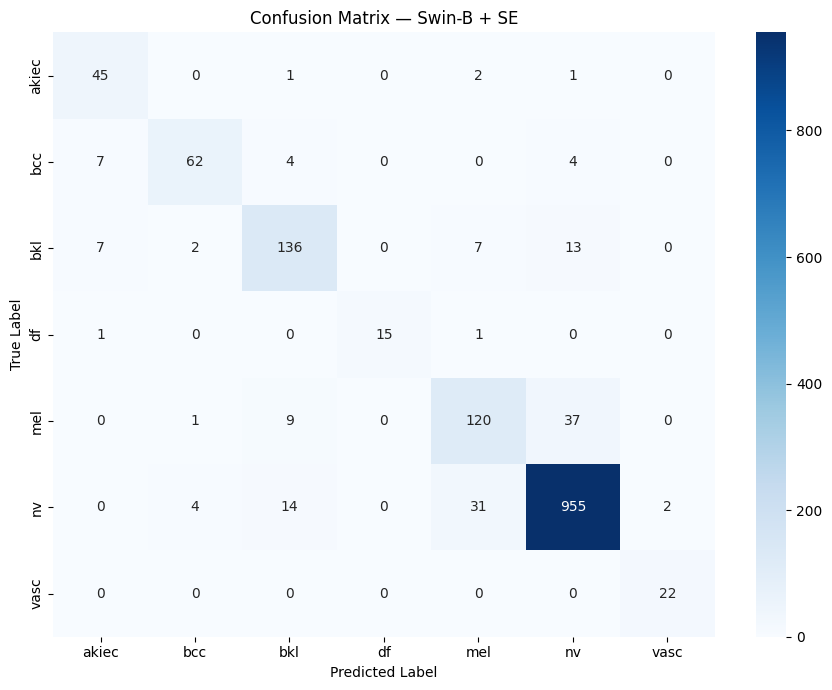

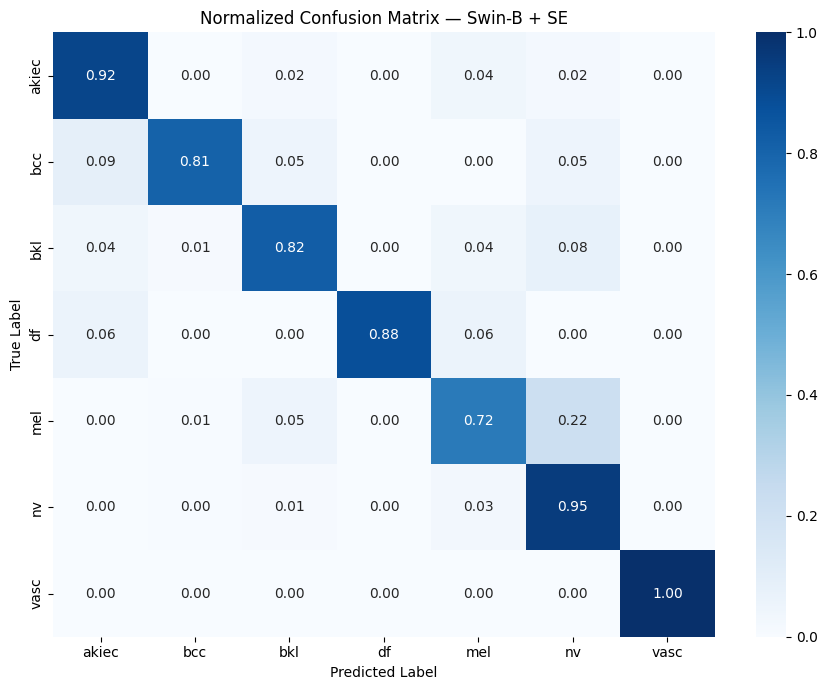

In [33]:
# Cell 19 — Confusion Matrix

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Swin-B + SE")
plt.tight_layout()
plt.savefig(PLOT_DIR / "confusion_matrix.png", dpi=200)
plt.show()

# Normalized confusion matrix
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix — Swin-B + SE")
plt.tight_layout()
plt.savefig(PLOT_DIR / "confusion_matrix_normalized.png", dpi=200)
plt.show()

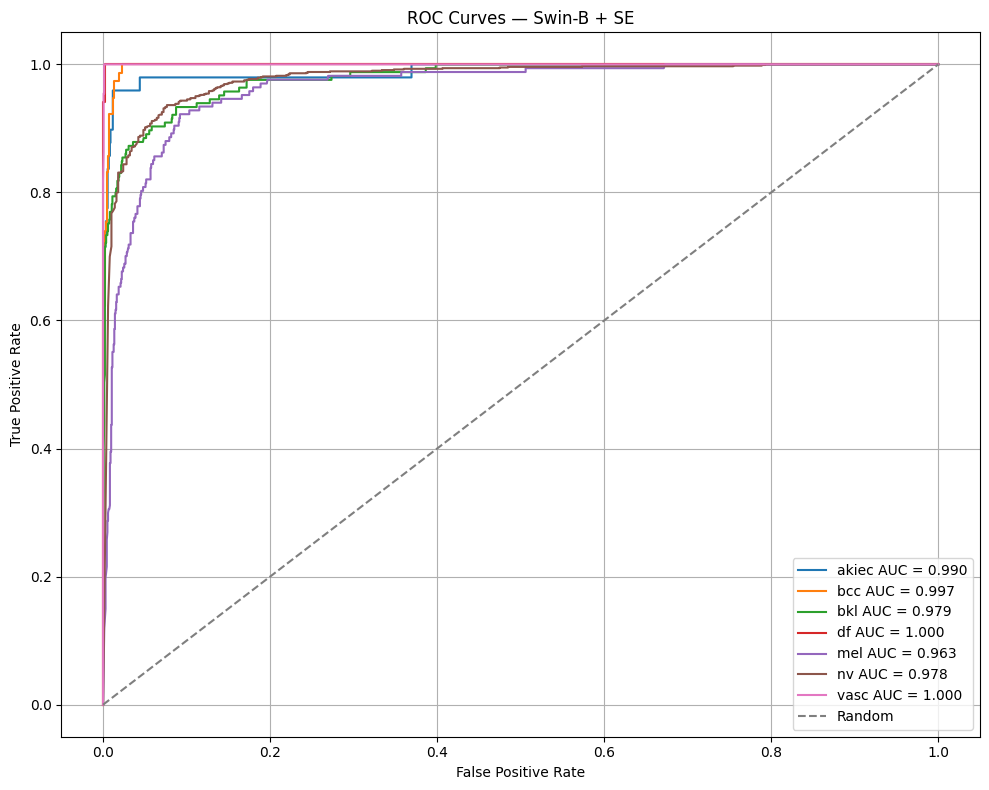

,class,auc
0,akiec,0.989635
1,bcc,0.997477
2,bkl,0.978555
3,df,0.999881
4,mel,0.962842
5,nv,0.977746
6,vasc,0.999862


In [34]:
# Cell 20 — ROC Curves and AUC

test_labels_onehot = np.eye(NUM_CLASSES)[test_labels]

fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(test_labels_onehot[:, i], test_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))

for i, cls_name in enumerate(CLASS_NAMES):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{cls_name} AUC = {roc_auc[i]:.3f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Swin-B + SE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOT_DIR / "roc_curves.png", dpi=200)
plt.show()

auc_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "auc": [roc_auc[i] for i in range(NUM_CLASSES)]
})

display(auc_df)
auc_df.to_csv(LOG_DIR / "per_class_auc.csv", index=False)

In [35]:
# Cell 21 — Save Final Model

final_model_path = MODEL_DIR / "final_swin_b_se_model.pth"

torch.save({
    "model_state_dict": unwrap_model(model).state_dict(),
    "class_to_idx": CLASS_TO_IDX,
    "idx_to_class": IDX_TO_CLASS,
    "config": {
        "model": "Swin Transformer-B + SE-Net Attention",
        "img_size": IMG_SIZE,
        "num_classes": NUM_CLASSES,
        "batch_size": BATCH_SIZE,
        "epochs": NUM_EPOCHS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    "use_synthetic_dcgan": USE_SYNTHETIC_DCGAN,
    "synthetic_source": "DCGAN"
    },
    "test_results": results
}, final_model_path)

print("Final model saved:", final_model_path)

Final model saved: /kaggle/working/model2_swin_b_se_dcgan_outputs/saved_models/final_swin_b_se_model.pth


In [36]:
# Cell 22 — Save Experiment Metadata

experiment_summary = {
    "model_name": "Swin Transformer-B + SE-Net Attention",
    "novel_component": "Swin Transformer-B",
    "established_component": "SE-Net attention block",
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "use_synthetic_dcgan": USE_SYNTHETIC_DCGAN,
    "synthetic_source": "DCGAN",
    "train_size": int(len(train_df)),
    "real_train_size": int(len(train_real_df)),
    "synthetic_train_size": int(len(synthetic_df)) if synthetic_df is not None else 0,
    "val_size": int(len(val_df)),
    "test_size": int(len(test_df)),
    "best_val_balanced_accuracy": float(best_val_bal_acc),
    "test_results": {
        k: float(v) if not pd.isna(v) else None
        for k, v in results.items()
    }
}

summary_path = LOG_DIR / "experiment_summary.json"

with open(summary_path, "w") as f:
    json.dump(experiment_summary, f, indent=4)

print(json.dumps(experiment_summary, indent=4))
print("Saved summary:", summary_path)

{
    "model_name": "Swin Transformer-B + SE-Net Attention",
    "novel_component": "Swin Transformer-B",
    "established_component": "SE-Net attention block",
    "num_classes": 7,
    "class_names": [
        "akiec",
        "bcc",
        "bkl",
        "df",
        "mel",
        "nv",
        "vasc"
    ],
    "image_size": 224,
    "batch_size": 16,
    "num_epochs": 30,
    "learning_rate": 5e-05,
    "weight_decay": 0.0001,
    "use_synthetic_dcgan": true,
    "synthetic_source": "DCGAN",
    "train_size": 31294,
    "real_train_size": 7009,
    "synthetic_train_size": 24285,
    "val_size": 1503,
    "test_size": 1503,
    "best_val_balanced_accuracy": 0.8826049724591992,
    "test_results": {
        "test_loss": 0.34721431772380135,
        "test_accuracy": 0.9015302727877578,
        "test_balanced_accuracy": 0.8711463666791815,
        "test_precision_macro": 0.8693388361927932,
        "test_recall_macro": 0.8711463666791815,
        "test_f1_macro": 0.8678429361966612

In [39]:
# Cell 23 — Zip All Outputs

zip_base_path = str(KAGGLE_WORKING / "/kaggle/working/model2_swin_b_se_dcgan_outputs")

zip_file_path = shutil.make_archive(
    base_name=zip_base_path,
    format="zip",
    root_dir=str(KAGGLE_WORKING),
    base_dir="model2_swin_b_se_dcgan_outputs"
)

print("ZIP file created:")
print(zip_file_path)

print("\nImportant files:")
print("Best model:", best_model_path)
print("Final model:", final_model_path)
print("Training history:", LOG_DIR / "training_history.csv")
print("Test results:", LOG_DIR / "test_results_summary.csv")
print("Confusion matrix:", PLOT_DIR / "confusion_matrix.png")
print("ROC curves:", PLOT_DIR / "roc_curves.png")
print("ZIP:", zip_file_path)

ZIP file created:
/kaggle/working/model2_swin_b_se_dcgan_outputs.zip

Important files:
Best model: /kaggle/working/model2_swin_b_se_dcgan_outputs/saved_models/best_swin_b_se_model.pth
Final model: /kaggle/working/model2_swin_b_se_dcgan_outputs/saved_models/final_swin_b_se_model.pth
Training history: /kaggle/working/model2_swin_b_se_dcgan_outputs/logs/training_history.csv
Test results: /kaggle/working/model2_swin_b_se_dcgan_outputs/logs/test_results_summary.csv
Confusion matrix: /kaggle/working/model2_swin_b_se_dcgan_outputs/plots/confusion_matrix.png
ROC curves: /kaggle/working/model2_swin_b_se_dcgan_outputs/plots/roc_curves.png
ZIP: /kaggle/working/model2_swin_b_se_dcgan_outputs.zip


In [41]:
from IPython.display import FileLink
FileLink(r'model2_swin_b_se_dcgan_outputs.zip')

/kaggle/working/model2_swin_b_se_dcgan_outputs.zip